In [36]:
import scanpy as sc
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
plt.rcParams['pdf.fonttype']=42
plt.rcParams.update({'font.sans-serif':'Helvetica'})
plt.rcParams.update({'font.size':7})

In [152]:
adata_tf=sc.read_h5ad("out/CID44971stf_results_tfa_only.h5ad")
adata_tf=adata_tf[adata_tf.obs['pathology'] !="Artefact"]
adata_tf=adata_tf[~adata_tf.obs['pathology'].isna()]

sc.pp.scale(adata_tf)
sc.pp.neighbors(adata_tf, use_rep='X', n_neighbors=50)
sc.tl.leiden(adata_tf, resolution=0.8)
sc.tl.umap(adata_tf)

adata= sc.read_h5ad("out/CID44971_stf_results.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[~adata.obs['pathology'].isna()]

sc.pp.normalize_total(adata)
adata.X=np.sqrt(adata.X)
sc.pp.scale(adata)
sc.pp.neighbors(adata,n_neighbors=50)
sc.tl.leiden(adata, resolution=0.66)
sc.tl.umap(adata)

/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


         Falling back to preprocessing with `sc.pp.pca` and default params.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


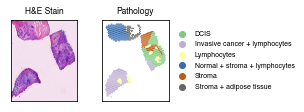

In [153]:
f, ax=plt.subplots(1, 2,figsize=(3,1.5))
sc.pl.spatial(adata, color='pathology', palette='Accent', alpha_img=0, size=1.6, ax=ax[1], show=False, title="Pathology")
sc.pl.spatial(adata,ax=ax[0], show=False, title="H&E Stain")
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[0].set_xlabel("")
ax[0].set_ylabel("")
plt.savefig("figures/CID44971_clustering_path.pdf", bbox_inches='tight', pad_inches=0)

0.4348475750815139
0.5325399785733906


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


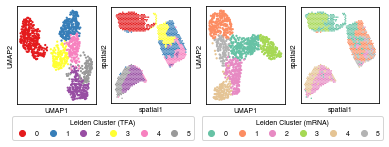

In [154]:
fig, axs = plt.subplots(1,4, figsize=(6.5,1.8))
sc.pl.umap(adata_tf, color="leiden", ax=axs[0], show=False, s=20, palette='Set1')
sc.pl.spatial(adata_tf, color='leiden', alpha_img=0, size=1.5, ax=axs[1], show=False, palette='Set1')
sc.pl.umap(adata, color="leiden", ax=axs[2], show=False, s=20, palette="Set2")
sc.pl.spatial(adata, color='leiden', size=1.5, alpha_img=0, ax=axs[3], show=False, palette="Set2")


for ax in axs.flatten():
    ax.set_ylabel(ax.get_ylabel(),labelpad=-1)
    ax.set_xlabel(ax.get_xlabel(),labelpad=-1)
    ax.set_title("")

axs[1].legend().remove()
axs[3].legend().remove()

axs[0].legend(title='Leiden Cluster (TFA)', loc='lower left',bbox_to_anchor=(-0.1,-0.4), ncol=6, columnspacing=1)
axs[2].legend(title='Leiden Cluster (mRNA)', loc='lower left',bbox_to_anchor=(-0.1,-0.4), ncol=6, columnspacing=1)
#plt.tight_layout()
print(adjusted_rand_score(adata.obs['leiden'], adata.obs['pathology']))
print(adjusted_rand_score(adata_tf.obs['leiden'], adata_tf.obs['pathology']))

plt.savefig("figures/CID44971_clustering_umaps.pdf", bbox_inches='tight', pad_inches=0)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


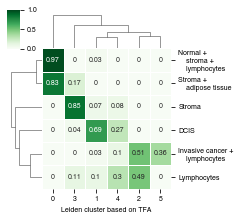

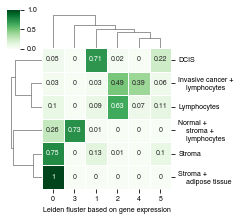

In [155]:
adata_tf.obs['pathology']=adata_tf.obs['pathology'].map(lambda x: x.replace("+","+ \n   "))
cax=sns.clustermap(
    adata_tf.obs['leiden'].groupby(adata_tf.obs['pathology']).value_counts(normalize=True).unstack(fill_value=0).round(2),
    figsize=(3.5,3), vmax=1,cmap='Greens',linewidth=1,
    annot=True)
cax.ax_heatmap.set_xlabel("Leiden cluster based on TFA")
cax.ax_heatmap.set_ylabel("")
plt.savefig("figures/CID44971_confusion_map_tfa.pdf", bbox_inches='tight', pad_inches=0)


adata.obs['pathology']=adata.obs['pathology'].map(lambda x: x.replace("+","+ \n   "))

cax=sns.clustermap(
    adata.obs['leiden'].groupby(adata.obs['pathology']).value_counts(normalize=True).unstack(fill_value=0).round(
        2),
    figsize=(3.5, 3), vmax=1, cmap='Greens', linewidth=1,
    annot=True)
cax.ax_heatmap.set_xlabel("Leiden fluster based on gene expression")
cax.ax_heatmap.set_ylabel("")
plt.savefig("figures/CID44971_confusion_map_gex.pdf", bbox_inches='tight', pad_inches=0)


In [157]:
adata_tf = sc.read_h5ad("out/CID4535stf_results_tfa_only.h5ad")
adata_tf=adata_tf[adata_tf.obs['pathology'] !="Artefact"]
adata_tf=adata_tf[adata_tf.obs['pathology'] !="Uncertain"]
adata_tf=adata_tf[adata_tf.obs['pathology'] != np.nan]

sc.pp.scale(adata_tf)
sc.pp.neighbors(adata_tf, use_rep='X')
sc.tl.leiden(adata_tf, resolution=0.55)
sc.tl.umap(adata_tf)

adata = sc.read_h5ad("out/CID4535_stf_results.h5ad")
adata=adata[adata.obs['pathology'] !="Artefact"]
adata=adata[adata.obs['pathology'] !="Uncertain"]
adata=adata[adata.obs['pathology'] !=np.nan]

sc.pp.normalize_total(adata)
adata.X = np.sqrt(adata.X)
sc.pp.scale(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=1)
sc.tl.umap(adata)

/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/aprilsagan/opt/anaconda3/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


         Falling back to preprocessing with `sc.pp.pca` and default params.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


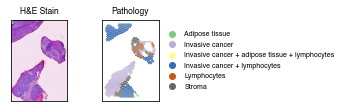

In [158]:
f, ax=plt.subplots(1, 2,figsize=(3,1.5))
sc.pl.spatial(adata, color='pathology', palette='Accent', alpha_img=0, size=1.6, ax=ax[1], show=False, title="Pathology",na_in_legend=False)
sc.pl.spatial(adata,ax=ax[0], show=False, title="H&E Stain")
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[0].set_xlabel("")
ax[0].set_ylabel("")

plt.savefig("figures/CID4535_clustering_path.pdf", bbox_inches='tight', pad_inches=0)


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


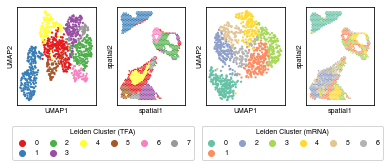

In [159]:
fig, axs = plt.subplots(1,4, figsize=(6.5,1.8))
sc.pl.umap(adata_tf, color="leiden", ax=axs[0], show=False, s=20, palette='Set1')
sc.pl.spatial(adata_tf, color='leiden', alpha_img=0, size=1.5, ax=axs[1], show=False, palette='Set1')
sc.pl.umap(adata, color="leiden", ax=axs[2], show=False, s=20, palette="Set2")
sc.pl.spatial(adata, color='leiden', size=1.5, alpha_img=0, ax=axs[3], show=False, palette="Set2")


for ax in axs.flatten():
    ax.set_ylabel(ax.get_ylabel(),labelpad=-1)
    ax.set_xlabel(ax.get_xlabel(),labelpad=-1)
    ax.set_title("")

axs[1].legend().remove()
axs[3].legend().remove()

axs[0].legend(title='Leiden Cluster (TFA)', loc='lower left',bbox_to_anchor=(-0.1,-0.6), ncol=6, columnspacing=1)
axs[2].legend(title='Leiden Cluster (mRNA)', loc='lower left',bbox_to_anchor=(-0.1,-0.6), ncol=6, columnspacing=1)
#plt.tight_layout()
# print(adjusted_rand_score(adata.obs['leiden'], adata.obs['pathology']))
# print(adjusted_rand_score(adata_tf.obs['leiden'], adata_tf.obs['pathology']))

plt.savefig("figures/CID4535_clustering_umaps.pdf", bbox_inches='tight', pad_inches=0)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
meta NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


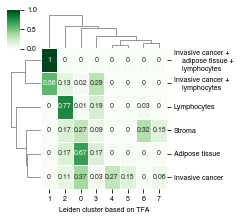

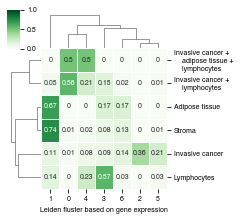

In [160]:
adata_tf.obs['pathology']=adata_tf.obs['pathology'].map(lambda x: x.replace("+","+ \n   "))
cax=sns.clustermap(
    adata_tf.obs['leiden'].groupby(adata_tf.obs['pathology']).value_counts(normalize=True).unstack(fill_value=0).round(2),
    figsize=(3.5,3), vmax=1,cmap='Greens',linewidth=1,
    annot=True)
cax.ax_heatmap.set_xlabel("Leiden cluster based on TFA")
cax.ax_heatmap.set_ylabel("")
plt.savefig("figures/CID4535_confusion_map_tfa.pdf", bbox_inches='tight', pad_inches=0)

adata.obs['pathology']=adata.obs['pathology'].map(lambda x: x.replace("+","+ \n   "))

cax=sns.clustermap(
    adata.obs['leiden'].groupby(adata.obs['pathology']).value_counts(normalize=True).unstack(fill_value=0).round(
        2),
    figsize=(3.5, 3), vmax=1, cmap='Greens', linewidth=1,
    annot=True)
cax.ax_heatmap.set_xlabel("Leiden fluster based on gene expression")
cax.ax_heatmap.set_ylabel("")
plt.savefig("figures/CID4535_confusion_map_gex.pdf", bbox_inches='tight', pad_inches=0)


In [ ]:
f, ax=plt.subplots(1, 2,figsize=(3,1.5))
sc.pl.spatial(adata, color='pathology', palette='Accent', alpha_img=0, size=1.6, ax=ax[1], show=False, title="Pathology")
sc.pl.spatial(adata,ax=ax[0], show=False, title="H&E Stain")
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[0].set_xlabel("")
ax[0].set_ylabel("")



fig, axs = plt.subplots(1,4, figsize=(6.5,1.8))
sc.pl.umap(adata_tf, color="leiden", ax=axs[0], show=False, s=20, palette='Set1')
sc.pl.spatial(adata_tf, color='leiden', alpha_img=0, size=1.5, ax=axs[1], show=False, palette='Set1')
sc.pl.umap(adata, color="leiden", ax=axs[2], show=False, s=20, palette="Set2")
sc.pl.spatial(adata, color='leiden', size=1.5, alpha_img=0, ax=axs[3], show=False, palette="Set2")


for ax in axs.flatten():
    ax.set_ylabel(ax.get_ylabel(),labelpad=-1)
    ax.set_xlabel(ax.get_xlabel(),labelpad=-1)
    ax.set_title("")

axs[1].legend().remove()
axs[3].legend().remove()

axs[0].legend(title='Leiden Cluster (TFA)', loc='lower left',bbox_to_anchor=(-0.1,-0.4), ncol=6, columnspacing=1)
axs[2].legend(title='Leiden Cluster (mRNA)', loc='lower left',bbox_to_anchor=(-0.1,-0.4), ncol=6, columnspacing=1)
#plt.tight_layout()
print(adjusted_rand_score(adata.obs['leiden'], adata.obs['pathology']))
print(adjusted_rand_score(adata_tf.obs['leiden'], adata_tf.obs['pathology']))

adata_tf.obs['pathology']=adata_tf.obs['pathology'].map(lambda x: x.replace("+","+ \n   "))
cax=sns.clustermap(
    adata_tf.obs['leiden'].groupby(adata_tf.obs['pathology']).value_counts(normalize=True).unstack(fill_value=0).round(2),
    figsize=(3.5,3), vmax=1,cmap='Greens',linewidth=1,
    annot=True)
cax.ax_heatmap.set_xlabel("Leiden cluster based on TFA")
cax.ax_heatmap.set_ylabel("")

adata.obs['pathology']=adata.obs['pathology'].map(lambda x: x.replace("+","+ \n   "))

cax=sns.clustermap(
    adata.obs['leiden'].groupby(adata.obs['pathology']).value_counts(normalize=True).unstack(fill_value=0).round(
        2),
    figsize=(3.5, 3), vmax=1, cmap='Greens', linewidth=1,
    annot=True)
cax.ax_heatmap.set_xlabel("Leiden fluster based on gene expression")
cax.ax_heatmap.set_ylabel("")

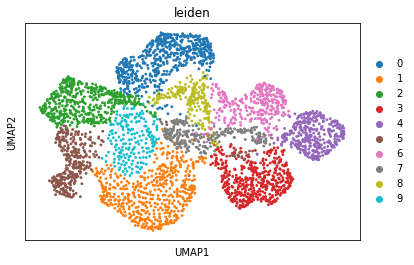

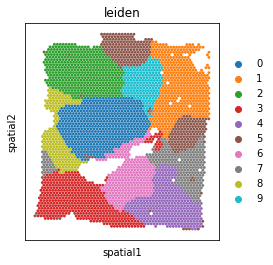

In [46]:
adata_tf=sc.read_h5ad("out/stf_results_tfa_only.h5ad")
sc.pp.scale(adata_tf)
sc.pp.neighbors(adata_tf, use_rep="X",n_neighbors=100)
sc.tl.leiden(adata_tf, resolution=0.5)
sc.tl.umap(adata_tf)
sc.pl.umap(adata_tf, color="leiden")
sc.pl.spatial(adata_tf, color='leiden', size=1.5, alpha_img=0)

         Falling back to preprocessing with `sc.pp.pca` and default params.


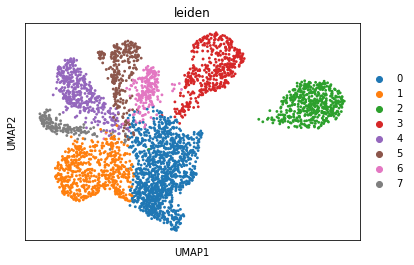

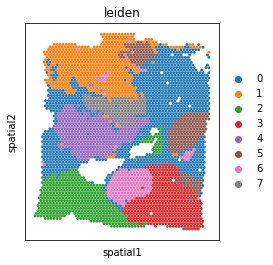

In [49]:
adata=sc.read_h5ad("out/stf_results.h5ad")
sc.pp.normalize_total(adata)
adata.X = np.sqrt(adata.X)
sc.pp.scale(adata)
sc.pp.neighbors(adata,n_neighbors=100)
sc.tl.leiden(adata, resolution=0.51)
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden")
sc.pl.spatial(adata, color="leiden", size=1.5, alpha_img=0)

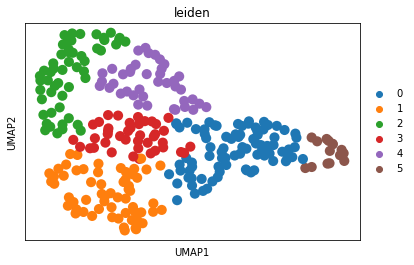

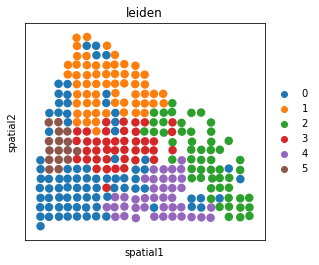

         Falling back to preprocessing with `sc.pp.pca` and default params.


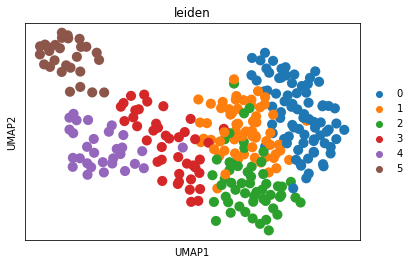

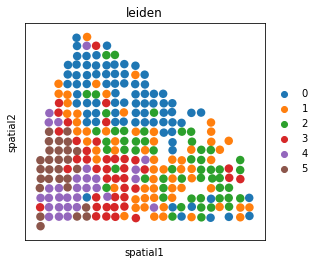

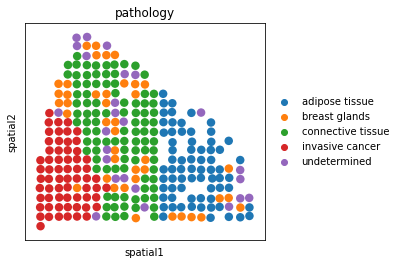

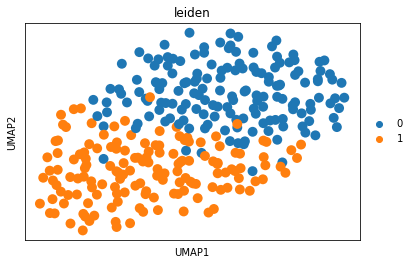

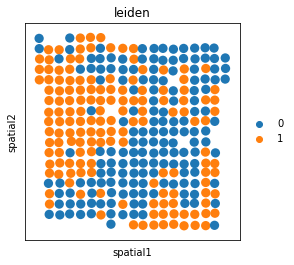

         Falling back to preprocessing with `sc.pp.pca` and default params.


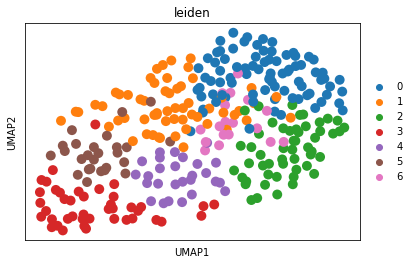

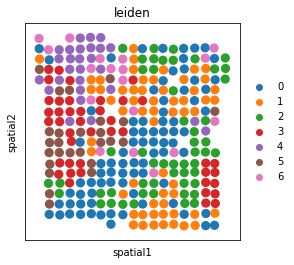

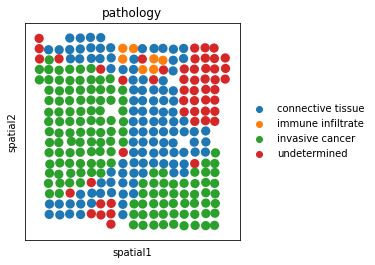

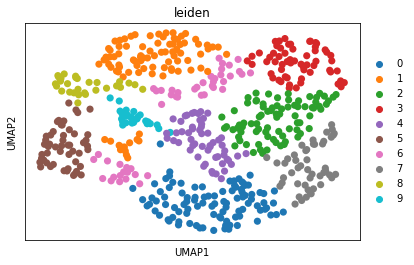

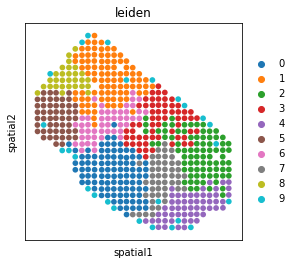

         Falling back to preprocessing with `sc.pp.pca` and default params.


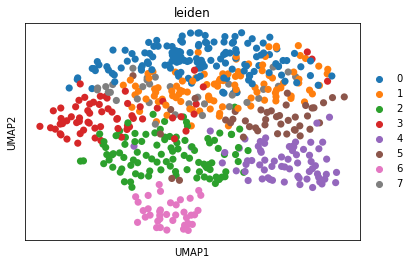

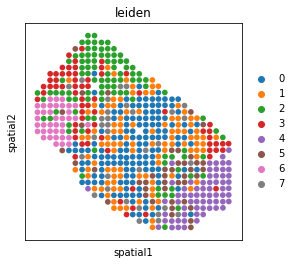

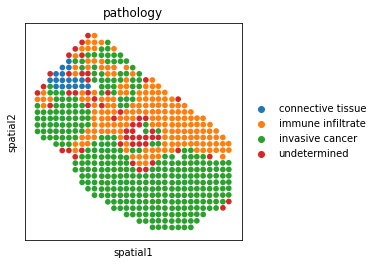

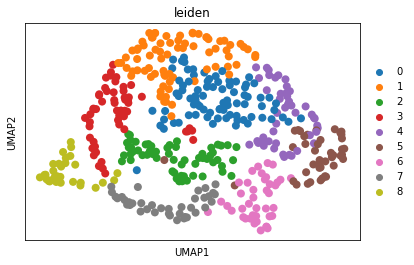

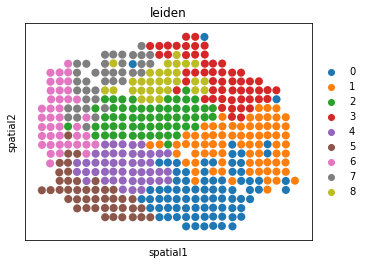

         Falling back to preprocessing with `sc.pp.pca` and default params.


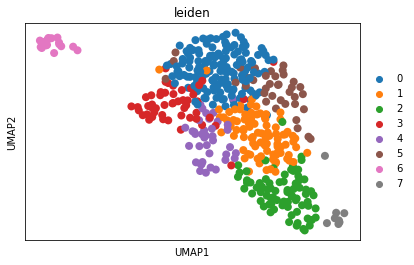

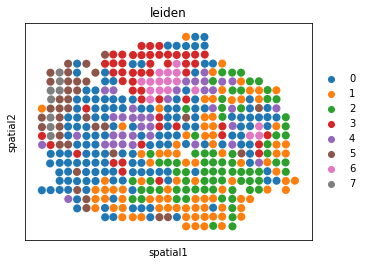

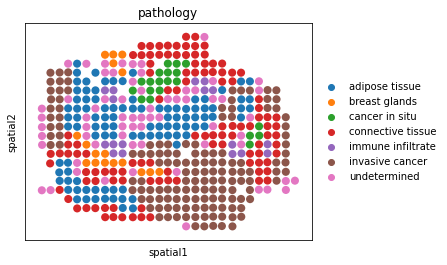

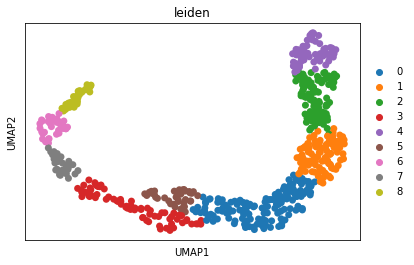

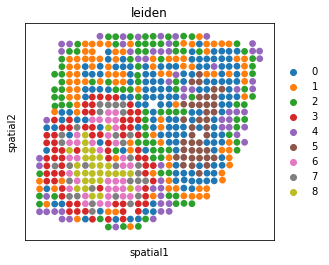

         Falling back to preprocessing with `sc.pp.pca` and default params.


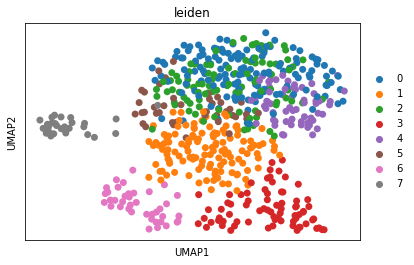

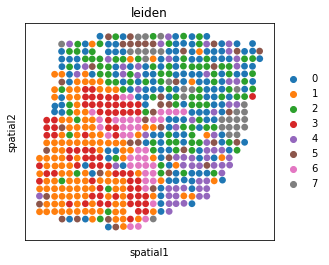

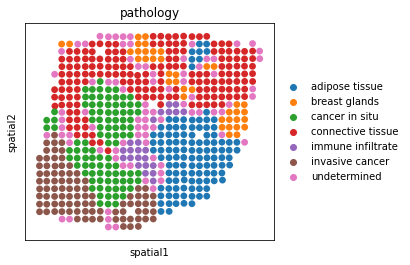

In [53]:
for sample in [ "B1", "D1", "E1", "G2", "H1"]:
    adata_tf = sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
    sc.pp.scale(adata_tf)
    sc.pp.neighbors(adata_tf, use_rep='X', n_neighbors=10)
    sc.tl.leiden(adata_tf, resolution=0.5)
    sc.tl.umap(adata_tf)
    sc.pl.umap(adata_tf, color="leiden")
    sc.pl.spatial(adata_tf, color='leiden', size=2, alpha_img=0)

    adata = sc.read_h5ad("out/"+sample+"_stf_results.h5ad")
    sc.pp.normalize_total(adata)
    adata.X = np.sqrt(adata.X)
    sc.pp.scale(adata)
    sc.pp.neighbors(adata, n_neighbors=10)
    sc.tl.leiden(adata, resolution=1)
    sc.tl.umap(adata)
    sc.pl.umap(adata, color="leiden")
    sc.pl.spatial(adata, color='leiden', size=2, alpha_img=0)

    sc.pl.spatial(adata_tf, color=['pathology'], size=2, alpha_img=0)

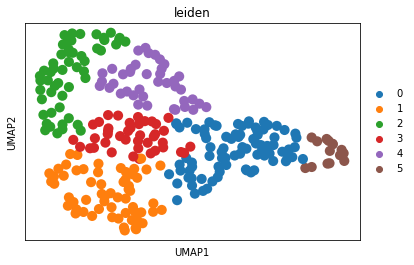

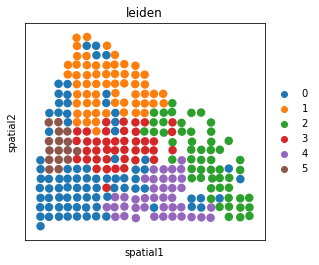

         Falling back to preprocessing with `sc.pp.pca` and default params.


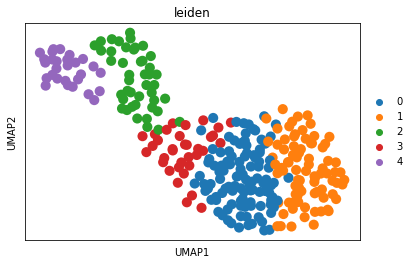

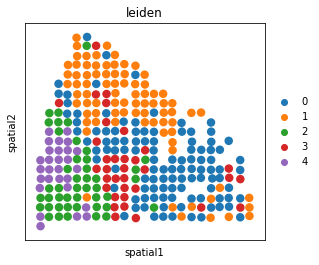

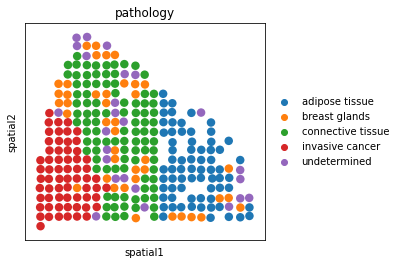

In [59]:
sample="B1"
adata_tf = sc.read_h5ad("out/"+sample+"stf_results_tfa_only.h5ad")
sc.pp.scale(adata_tf)
sc.pp.neighbors(adata_tf, use_rep='X', n_neighbors=10)
sc.tl.leiden(adata_tf, resolution=0.5)
sc.tl.umap(adata_tf)
sc.pl.umap(adata_tf, color="leiden")
sc.pl.spatial(adata_tf, color='leiden', size=2, alpha_img=0)

adata = sc.read_h5ad("out/"+sample+"_stf_results.h5ad")
sc.pp.normalize_total(adata)
adata.X = np.sqrt(adata.X)
sc.pp.scale(adata)
sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.leiden(adata, resolution=1)
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden")
sc.pl.spatial(adata, color='leiden', size=2, alpha_img=0)

sc.pl.spatial(adata_tf, color=['pathology'], size=2, alpha_img=0)

In [58]:
adata_tf

AnnData object with n_obs × n_vars = 613 × 205
    obs: 'Total Reads', 'pathology', 'sample', 'replicate', 'source', 'ER', 'HER2', 'PR', 'subtype', 'n_counts', 'pixel_intensity', 'pred_cor_stl', 'pred_cor_stan', 'leiden'
    var: 'mean', 'std'
    uns: 'spatial', 'tf_names', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'celltype_major', 'celltype_minor', 'celltype_subset', 'kernel', 'pixel_intensity', 'spatial', 'spatial_int', 'X_umap'
    layers: 'stan_tfa', 'stl_tfa'
    obsp: 'distances', 'connectivities'